In [1]:
from pathlib import Path
import os
import sys

# Make repo imports work even when the kernel starts inside a notebook subdirectory.
_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / 'configs' / 'profiles.py').exists():
    _repo_root = _repo_root.parent
if not (_repo_root / 'configs' / 'profiles.py').exists():
    raise RuntimeError("Failed to locate MADRL_ESS repo root containing configs/profiles.py.")
_repo_root_str = str(_repo_root)
if _repo_root_str not in sys.path:
    sys.path.insert(0, _repo_root_str)
os.chdir(_repo_root)


# Forecast LSTM

以 canonical 3-agent 配置为准，重训或读取现有 LSTM artifact，并把一周测试结果与 shared-data 记录统一写入 `notebooks/record/forecast/lstm/`。

In [2]:

from pathlib import Path
from pprint import pprint
import copy
import json

import numpy as np
import pandas as pd
from IPython.display import display

from configs.profiles import compose_experiment_config, project_root
from data.loaders.prosumer import ProsumerDataset
from predictors.lstm_forecaster import LSTMForecaster
from predictors.mainline_forecast import get_mainline_forecast_controls
from predictors.shared_data import ensure_madrl_shared_data
from predictors.time_features import DEFAULT_LOCAL_TIMEZONE, coerce_timestamp_index, infer_timestamp_step
from predictors.training import (
    _load_signal_matrix_from_source as load_signal_matrix_from_source,
    _resolve_prosumer_dataset_kwargs,
    ensure_lstm_artifacts,
    resolve_signal_csv_source,
    resolve_signal_physical_scale_from_source,
    train_signal_lstm,
)
from scripts.utils.grid_notebook_workflow import apply_notebook_experiment_settings, get_notebook_record_root
from scripts.utils.torch_runtime import configure_torch_runtime, describe_device


In [3]:

# 唯一 notebook 参数：True 时重训全部 LSTM；False 时严格读取现有 canonical artifact。
force_retrain_forecast = False


In [4]:

root = project_root()
record_dir = get_notebook_record_root(root) / 'forecast' / 'lstm'
cfg = compose_experiment_config(
    forecast_type='lstm',
    data_dir=root / 'data',
    runtime_mode='performance',
    seed=0,
)
forecast_controls = get_mainline_forecast_controls(auto_train_missing=False)
apply_summary = apply_notebook_experiment_settings(
    cfg,
    prediction_mode='normal',
    test_start_date=None,
    test_end_date=None,
    agent_profiles=None,
    agent_bus_ids=None,
    load_scale=None,
    pv_scale=None,
    future_horizon=int(forecast_controls['future_horizon']),
    battery_controls=None,
    forecast_controls=forecast_controls,
    train_year=None,
    test_year=None,
)
cfg.forecast.auto_train_missing = False
runtime_state = configure_torch_runtime(cfg, seed=cfg.runtime.seed)
cfg.runtime.device = runtime_state.device

config_snapshot = {
    'force_retrain_forecast': bool(force_retrain_forecast),
    'agent_profiles': list(cfg.data.agent_profiles),
    'agent_bus_ids': list(cfg.grid.agent_bus_ids),
    'test_start_date': str(cfg.data.test_start_date),
    'test_end_date': str(cfg.data.test_end_date),
    'history_window': int(cfg.forecast.history_window),
    'future_horizon': int(cfg.env.future_horizon),
    'forecast_artifact_root': str(cfg.forecast.lstm_artifact_root),
    'device': str(runtime_state.device),
    'device_info': describe_device(runtime_state),
}
display(pd.DataFrame([config_snapshot]))
pprint(apply_summary)


,force_retrain_forecast,agent_profiles,agent_bus_ids,test_start_date,test_end_date,history_window,future_horizon,forecast_artifact_root,device,device_info
0,False,"[SFH12, SFH18, SFH20]","[12, 4, 2]",2020-04-01,2020-04-15,192,48,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...,cuda:0,"{'device': 'cuda:0', 'cuda_available': True, '..."


{'agent_bus_ids': [12, 4, 2],
 'agent_profiles': ['SFH12', 'SFH18', 'SFH20'],
 'battery': {'battery_capacity': [100.0, 100.0, 100.0],
             'efficiency': 0.95,
             'init_soc': 0.5,
             'max_charge_rate': 0.5,
             'mode': 'fixed',
             'p_max_kw': [50.0, 50.0, 50.0],
             'soc_max': 0.95,
             'soc_min': 0.05,
             'soc_target': 0.05,
             'train_init_soc_high': 0.8,
             'train_init_soc_low': 0.2},
 'evaluation_mode': 'forecast_eval',
 'forecast': {'artifact_root': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\forecast\\lstm',
              'auto_train_missing': False,
              'history_window': 192,
              'load_component_split': True,
              'load_scaler_type': 'robust',
              'signal_training_overrides': {'load': {'batch_size': 1024,
                                                     'dropout': 0.1,
                                                     'ep

In [5]:

# 这里不做兼容兜底：要么明确重训，要么严格读取当前 canonical artifact。
if force_retrain_forecast:
    for signal_name in cfg.forecast.target_signals:
        overrides = dict(cfg.forecast.signal_training_overrides.get(signal_name) or {})
        train_signal_lstm(
            cfg,
            signal_name,
            device=runtime_state.device,
            overrides=overrides or None,
            show_progress=True,
            compute_evaluations=False,
        )

artifact_inventory = ensure_lstm_artifacts(cfg, device=runtime_state.device)
artifact_map = dict(artifact_inventory['artifacts'])
artifact_table = pd.DataFrame(
    [
        {
            'signal_name': signal_name,
            'artifact_count': len(bundle) if isinstance(bundle, list) else 1,
            'artifact_root': str(cfg.forecast.lstm_artifact_root),
        }
        for signal_name, bundle in artifact_map.items()
    ]
)
display(artifact_table)


,signal_name,artifact_count,artifact_root
0,wholesale_price,1,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...
1,load,6,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...
2,pv,1,C:\Users\10856\Desktop\GithubProject\MADRL_ESS...


In [6]:

def _json_default(value):
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    raise TypeError(f'Object of type {type(value).__name__} is not JSON serializable')


def _normalize_local_timestamp_index(timestamps) -> pd.DatetimeIndex:
    timestamp_index = coerce_timestamp_index(timestamps)
    if len(timestamp_index) == 0:
        return pd.DatetimeIndex([])
    if getattr(timestamp_index, 'tz', None) is None:
        return timestamp_index.tz_localize(DEFAULT_LOCAL_TIMEZONE)
    return timestamp_index.tz_convert(DEFAULT_LOCAL_TIMEZONE)


def _build_local_date_mask(timestamps, *, start_date: str, end_date: str) -> np.ndarray:
    start_local = pd.Timestamp(start_date).date()
    end_local = pd.Timestamp(end_date).date()
    timestamp_index = _normalize_local_timestamp_index(timestamps)
    local_dates = pd.Series(timestamp_index.date).reset_index(drop=True)
    return local_dates.between(start_local, end_local).to_numpy(dtype=bool)


def _build_forecaster(signal_name: str) -> LSTMForecaster:
    bundle = artifact_map[signal_name]
    if isinstance(bundle, tuple) and len(bundle) == 3 and not any(isinstance(item, (list, tuple)) for item in bundle):
        model_path, meta_path, scaler_path = bundle
        return LSTMForecaster.from_artifacts(
            model_path=model_path,
            meta_path=meta_path,
            scaler_path=scaler_path,
            device=runtime_state.device,
            signal_name=signal_name,
        )
    return LSTMForecaster.from_signal_artifacts({signal_name: bundle}, device=runtime_state.device)


def _build_padded_test_dataset_kwargs(source) -> dict[str, object]:
    dataset_kwargs = dict((source.dataset_kwargs or {}).get('test') or {})
    if not dataset_kwargs:
        raise ValueError("Prosumer signal source is missing dataset kwargs for split='test'.")
    dataset = ProsumerDataset(**dataset_kwargs)
    timestamp_index = _normalize_local_timestamp_index(dataset._timestamps)
    if len(timestamp_index) == 0:
        raise ValueError('Test split does not contain any timestamps for forecast evaluation.')
    history_window = int(cfg.forecast.history_window)
    canonical_start_local = pd.Timestamp(str(cfg.data.test_start_date)).tz_localize(DEFAULT_LOCAL_TIMEZONE)
    padded_start_local = canonical_start_local - history_window * infer_timestamp_step(timestamp_index)
    padded_dataset_kwargs = dict(dataset_kwargs)
    padded_dataset_kwargs['start_date'] = padded_start_local.date().isoformat()
    return padded_dataset_kwargs


def _load_padded_test_signal_matrix(source, signal_name: str):
    padded_source = copy.deepcopy(source)
    padded_source.dataset_kwargs = dict(source.dataset_kwargs or {})
    padded_source.dataset_kwargs['test'] = _build_padded_test_dataset_kwargs(source)
    padded_frame, padded_values, value_columns = load_signal_matrix_from_source(padded_source, signal_name, split='test')
    return padded_source, padded_frame.reset_index(drop=True), np.asarray(padded_values, dtype=np.float32), value_columns


def _load_component_test_signals(*, source) -> dict[str, np.ndarray]:
    dataset = ProsumerDataset(**_build_padded_test_dataset_kwargs(source))
    return {
        key: np.asarray(value, dtype=np.float32)
        for key, value in dataset._signals.items()
        if key.startswith('load_')
    }


def _build_signal_episode_meta(signal_name: str, source):
    physical_scale = resolve_signal_physical_scale_from_source(source, signal_name, split='test')
    if physical_scale is None:
        return None
    scale_values = np.asarray(physical_scale, dtype=np.float32).reshape(-1).tolist()
    if signal_name == 'load':
        return {'load_scale': scale_values}
    if signal_name == 'pv':
        return {'pv_peak_kw': scale_values}
    return None


def _rolling_test_predictions(signal_name: str):
    source = resolve_signal_csv_source(Path(cfg.data.data_dir), signal_name, cfg=cfg)
    if source is None:
        raise FileNotFoundError(f'No test source available for signal={signal_name!r}.')
    _, test_frame, test_values, value_columns = _load_padded_test_signal_matrix(source, signal_name)
    canonical_mask = _build_local_date_mask(
        test_frame['timestamp'],
        start_date=str(cfg.data.test_start_date),
        end_date=str(cfg.data.test_end_date),
    )
    if not np.any(canonical_mask):
        raise ValueError(
            f'signal={signal_name!r} has no rows inside canonical test window '
            f'{cfg.data.test_start_date} -> {cfg.data.test_end_date}.',
        )

    values = np.asarray(test_values, dtype=np.float32)
    if values.ndim == 1:
        values = values.reshape(-1, 1)

    forecaster = _build_forecaster(signal_name)
    history_window = int(cfg.forecast.history_window)
    has_component_runtimes = any(
        getattr(runtime, 'component', None) is not None
        for runtimes in forecaster.signal_runtimes.values()
        for runtime in runtimes
    )
    component_test_signals = (
        _load_component_test_signals(source=source)
        if has_component_runtimes
        else {}
    )
    episode_meta = _build_signal_episode_meta(signal_name, source)

    working_frame = test_frame.copy()
    if 'segment_id' not in working_frame.columns:
        working_frame['segment_id'] = 0
    working_frame['segment_id'] = working_frame['segment_id'].fillna(0).astype(int)

    segments = []
    for segment_id in sorted(working_frame['segment_id'].unique()):
        segment_mask = working_frame['segment_id'] == segment_id
        segment_frame = working_frame.loc[segment_mask].reset_index(drop=True)
        segment_values = values[segment_mask.to_numpy()]
        segment_canonical_mask = canonical_mask[segment_mask.to_numpy()]
        target_indices = np.flatnonzero(segment_canonical_mask)
        if target_indices.size == 0:
            continue
        if int(target_indices[0]) < history_window:
            raise ValueError(
                f'signal={signal_name!r} cannot provide {history_window} history steps before canonical test window '
                f'{cfg.data.test_start_date} -> {cfg.data.test_end_date}.',
            )
        segment_component_signals = {
            key: np.asarray(value, dtype=np.float32)[segment_mask.to_numpy()]
            for key, value in component_test_signals.items()
        }

        timestamps = []
        target_rows = []
        prediction_rows = []
        for end_idx in target_indices:
            history = segment_values[end_idx - history_window:end_idx]
            history_timestamps = segment_frame.iloc[end_idx - history_window:end_idx]['timestamp'].tolist()
            if has_component_runtimes or episode_meta is not None:
                step_episode_signals = {
                    key: value[end_idx - history_window:end_idx]
                    for key, value in segment_component_signals.items()
                }
                forecaster.set_episode(step_episode_signals, episode_meta=episode_meta)
            rollout = np.asarray(
                forecaster.predict(
                    history,
                    horizon=2,
                    signal_name=signal_name,
                    history_timestamps=history_timestamps,
                ),
                dtype=np.float32,
            )
            prediction = np.array([rollout[1]], dtype=np.float32) if rollout.ndim == 1 else rollout[:, 1].astype(np.float32)
            prediction_rows.append(prediction)
            target_rows.append(segment_values[end_idx].astype(np.float32))
            timestamps.append(segment_frame.iloc[end_idx]['timestamp'])

        segments.append(
            {
                'segment_id': int(segment_id),
                'timestamps': _normalize_local_timestamp_index(timestamps),
                'target': np.stack(target_rows, axis=0),
                'prediction': np.stack(prediction_rows, axis=0),
            }
        )

    if not segments:
        raise ValueError(
            f'signal={signal_name!r} has no rows inside canonical test window with usable history_window={history_window} '
            f'inside canonical test window.',
        )

    return {
        'signal_name': signal_name,
        'value_columns': list(value_columns),
        'segments': segments,
    }


In [7]:

def _flatten_prediction_view(view):
    rows = []
    for segment in view['segments']:
        timestamps = _normalize_local_timestamp_index(segment['timestamps'])
        for series_idx, series_name in enumerate(view['value_columns']):
            target_curve = np.asarray(segment['target'][:, series_idx], dtype=np.float64)
            prediction_curve = np.asarray(segment['prediction'][:, series_idx], dtype=np.float64)
            abs_error = np.abs(prediction_curve - target_curve)
            sq_error = np.square(prediction_curve - target_curve)
            denominator = np.where(np.abs(target_curve) > 1e-6, np.abs(target_curve), np.nan)
            rows.append(
                pd.DataFrame(
                    {
                        'timestamp': timestamps,
                        'segment_id': int(segment['segment_id']),
                        'signal_name': str(view['signal_name']),
                        'series_name': str(series_name),
                        'target': target_curve.astype(np.float32),
                        'prediction': prediction_curve.astype(np.float32),
                        'abs_error': abs_error.astype(np.float32),
                        'sq_error': sq_error.astype(np.float32),
                        'ape': (abs_error / denominator).astype(np.float32),
                    }
                )
            )
    return pd.concat(rows, ignore_index=True)


prediction_views = [_rolling_test_predictions(signal_name) for signal_name in cfg.forecast.target_signals]
predictions_df = pd.concat([_flatten_prediction_view(view) for view in prediction_views], ignore_index=True)
metrics_df = (
    predictions_df.groupby('signal_name', as_index=False)
    .agg(
        row_count=('signal_name', 'size'),
        segment_count=('segment_id', 'nunique'),
        series_count=('series_name', 'nunique'),
        rmse=('sq_error', lambda values: float(np.sqrt(np.mean(values)))),
        mae=('abs_error', lambda values: float(np.mean(values))),
        mape_pct=('ape', lambda values: None if pd.Series(values).dropna().empty else float(pd.Series(values).dropna().mean() * 100.0)),
    )
    .sort_values('signal_name')
    .reset_index(drop=True)
)

shared_data_result = ensure_madrl_shared_data(cfg, root=root)
shared_data_record = {
    'shared_data_dir': str(shared_data_result.shared_data_dir),
    'signature_hash': str(shared_data_result.signature_hash),
    'reused': bool(shared_data_result.reused),
    'train_split_episodes': int(shared_data_result.manifest['splits']['train']['num_episodes']),
    'test_split_episodes': int(shared_data_result.manifest['splits']['test']['num_episodes']),
    'schema_version': int(shared_data_result.manifest['schema_version']),
    'price_protocol_version': int(shared_data_result.manifest['price_protocol_version']),
}

record_dir.mkdir(parents=True, exist_ok=True)
predictions_df.to_parquet(record_dir / 'predictions.parquet', index=False)
metrics_df.to_parquet(record_dir / 'metrics.parquet', index=False)
(record_dir / 'config_snapshot.json').write_text(json.dumps(config_snapshot, indent=2, default=_json_default), encoding='utf-8')
(record_dir / 'shared_data_record.json').write_text(json.dumps(shared_data_record, indent=2, default=_json_default), encoding='utf-8')
manifest = {
    'schema_version': 1,
    'record_dir': str(record_dir),
    'force_retrain_forecast': bool(force_retrain_forecast),
    'test_window': {
        'start_date': str(cfg.data.test_start_date),
        'end_date': str(cfg.data.test_end_date),
    },
    'artifact_map': artifact_map,
    'files': {
        'predictions': 'predictions.parquet',
        'metrics': 'metrics.parquet',
        'config_snapshot': 'config_snapshot.json',
        'shared_data_record': 'shared_data_record.json',
    },
    'shared_data_signature': shared_data_record['signature_hash'],
}
(record_dir / 'manifest.json').write_text(json.dumps(manifest, indent=2, default=_json_default), encoding='utf-8')

display(metrics_df)
pprint(shared_data_record)


,signal_name,row_count,segment_count,series_count,rmse,mae,mape_pct
0,load,4320,1,3,14.905880,9.697828,116.986336
1,pv,4320,1,3,0.932213,0.499810,89.162048
2,wholesale_price,1440,1,1,0.034056,0.023956,169.275650


{'price_protocol_version': 1,
 'reused': True,
 'schema_version': 7,
 'shared_data_dir': 'C:\\Users\\10856\\Desktop\\GithubProject\\MADRL_ESS\\artifacts\\training\\shared_data\\mainline\\22a77ba3c2ee3138',
 'signature_hash': '22a77ba3c2ee3138',
 'test_split_episodes': 364,
 'train_split_episodes': 356}


In [8]:
# 释放 forecast 阶段占用的显存和大对象，避免影响后续 notebook 计算。
import gc
import matplotlib.pyplot as plt
import torch

_cleanup_names = [
    'prediction_views',
    'predictions_df',
    'metrics_df',
    'artifact_inventory',
    'artifact_map',
    'shared_data_result',
    'shared_data_record',
    'manifest',
    'config_snapshot',
    'runtime_state',
]
for _name in _cleanup_names:
    if _name in globals():
        del globals()[_name]

plt.close('all')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('forecast cleanup finished')


forecast cleanup finished


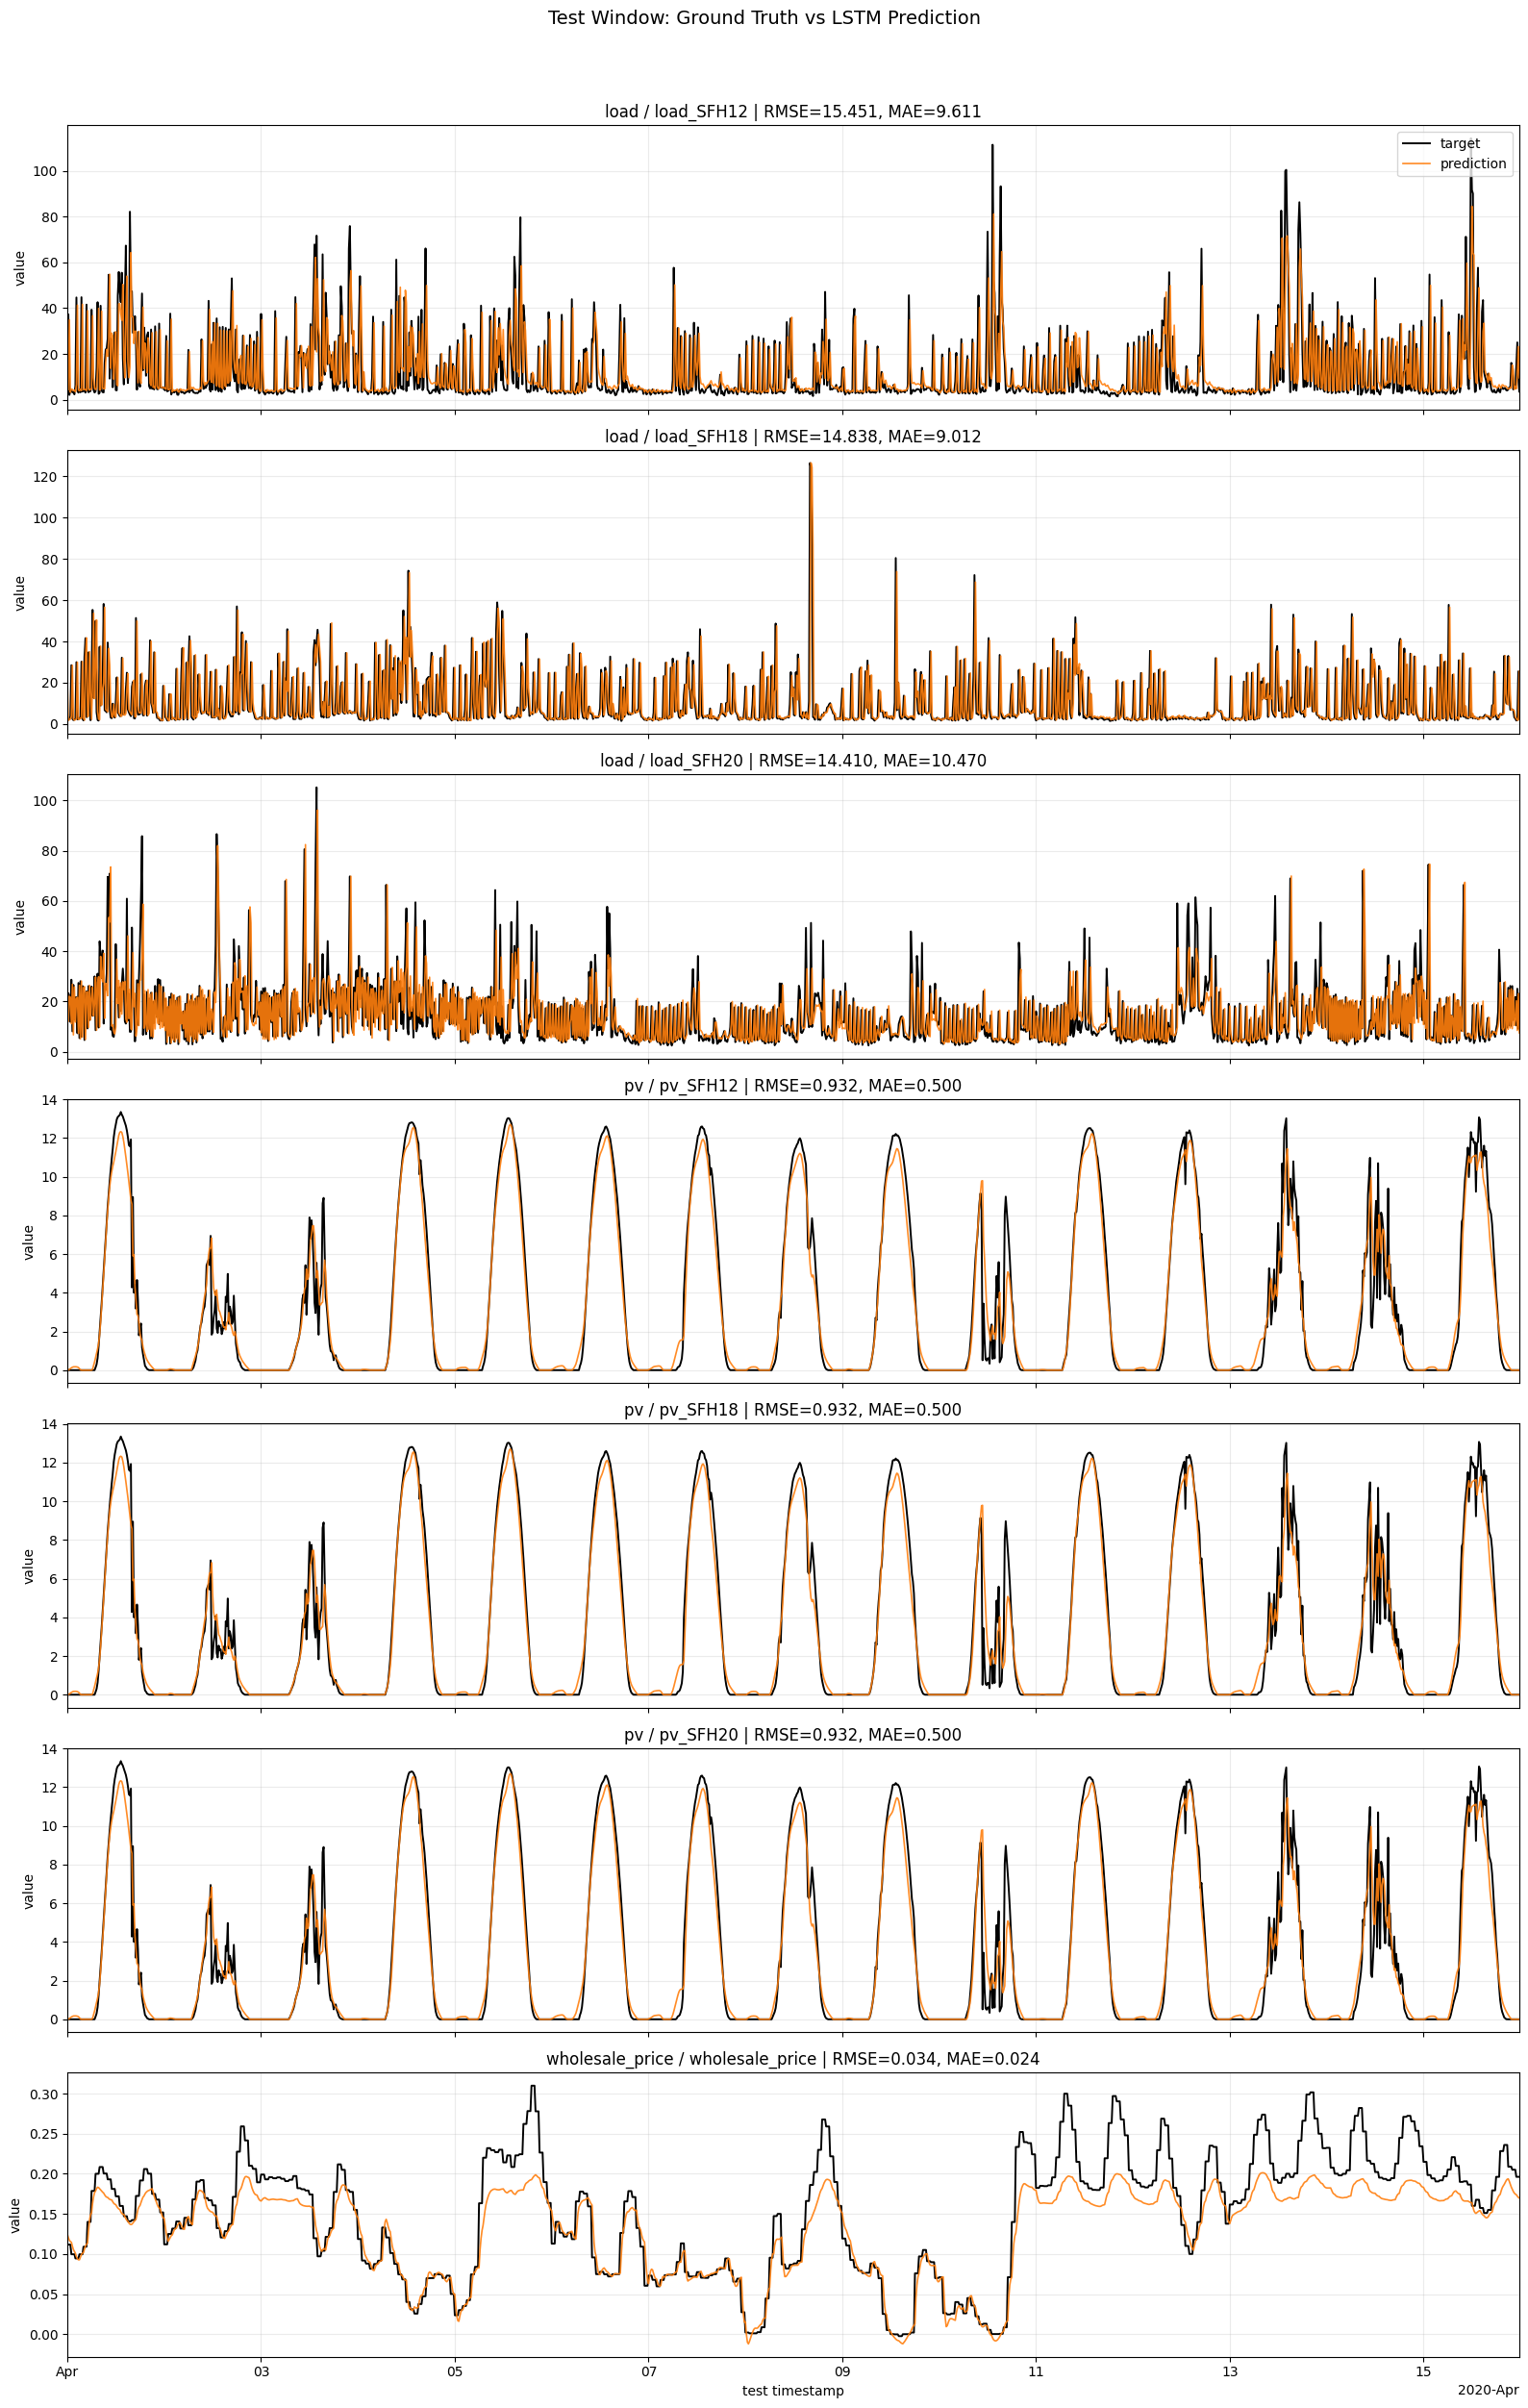

In [9]:
# 读取保存好的测试集预测结果，按 signal/series 画真值与预测值对比。
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if 'record_dir' not in globals():
    raise NameError('record_dir is not defined. Run the notebook setup cells first to populate the forecast record directory.')

predictions_path = record_dir / 'predictions.parquet'
if not predictions_path.exists():
    raise FileNotFoundError(
        f'Missing predictions file at {predictions_path}. Run the forecast evaluation cell first to regenerate predictions.parquet.'
    )

if '_normalize_local_timestamp_index' not in globals():
    raise NameError('_normalize_local_timestamp_index is not defined. Run the notebook forecast helper cells first.')

plot_df = pd.read_parquet(predictions_path).copy()
plot_df['timestamp'] = pd.DatetimeIndex(_normalize_local_timestamp_index(plot_df['timestamp'])).tz_localize(None)
x_min = plot_df['timestamp'].min()
x_max = plot_df['timestamp'].max()

series_keys = list(
    plot_df[['signal_name', 'series_name']]
    .drop_duplicates()
    .sort_values(['signal_name', 'series_name'])
    .itertuples(index=False, name=None)
)
if not series_keys:
    raise ValueError(f'No prediction rows found in {predictions_path}.')

fig, axes = plt.subplots(
    len(series_keys),
    1,
    figsize=(16, max(3.5 * len(series_keys), 4)),
    sharex=True,
)
if len(series_keys) == 1:
    axes = [axes]

for ax, (signal_name, series_name) in zip(axes, series_keys):
    series_df = (
        plot_df.loc[
            (plot_df['signal_name'] == signal_name)
            & (plot_df['series_name'] == series_name)
        ]
        .sort_values(['segment_id', 'timestamp'])
        .reset_index(drop=True)
    )
    rmse = float(np.sqrt(series_df['sq_error'].mean()))
    mae = float(series_df['abs_error'].mean())

    first_segment = True
    for _, segment_df in series_df.groupby('segment_id', sort=True):
        ax.plot(
            segment_df['timestamp'],
            segment_df['target'],
            color='black',
            linewidth=1.4,
            label='target' if first_segment else None,
        )
        ax.plot(
            segment_df['timestamp'],
            segment_df['prediction'],
            color='tab:orange',
            linewidth=1.2,
            alpha=0.9,
            label='prediction' if first_segment else None,
        )
        first_segment = False

    ax.set_title(f'{signal_name} / {series_name} | RMSE={rmse:.3f}, MAE={mae:.3f}')
    ax.set_ylabel('value')
    ax.grid(True, alpha=0.25)

axes[0].legend(loc='upper right')
axes[-1].set_xlabel('test timestamp')
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
formatter = mdates.ConciseDateFormatter(locator)
for ax in axes:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    if pd.notna(x_min) and pd.notna(x_max):
        ax.set_xlim(x_min, x_max)

fig.suptitle('Test Window: Ground Truth vs LSTM Prediction', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()
